# **CS503 PROJECT: Music Genre Classification**

---

### **Project Members**
| Name | Entry Number |
| :--- | :--- |
| **Hardik Rangi** | 2023MCB1203 |
| **Jagrati Gupta** | 2023MCB1211 |
| **Nishit Soni** | 2023MCB1304 |

---

### **Instructors**
* **Dr. Shweta Jain**
* **Dr. Vandana Bharti**

### **Mentor**
* **Akanksha Chuchra**

---




### Importing Necessary Libraries and Tools



In [ ]:
# Core Libraries
import os
import warnings
import numpy as np
import pandas as pd

# Libraries for Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize


# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split

# Torchvision (Image Models & Transforms)
from torchvision import datasets, transforms, models

# Torchaudio (Audio Processing)
import torchaudio

# Transformers (Wav2Vec2)
try:
    from transformers import (
        Wav2Vec2Processor,
        Wav2Vec2Model,
        AutoProcessor,
        AutoModel
    )
except ImportError:
    pass


# Utilities
from tqdm import tqdm

# Google Colab (File Uploads)
from google.colab import files

# Settings
warnings.filterwarnings('ignore')

try:
    from transformers import Wav2Vec2Processor, Wav2Vec2Model
except ImportError:
    pass

warnings.filterwarnings('ignore')




### Setup and Dataset Acquisition
Downloading the GTZAN dataset directly from Kaggle using the Kaggle API.
Note: Ensure that `kaggle.json` is properly configured in your `~/.kaggle/` directory.

In [ ]:
#Install & Setup Kaggle
!pip install -q kaggle

files.upload()  #Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#Download Dataset

if not os.path.exists("/content/Data"):
    !kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification
    !unzip -q gtzan-dataset-music-genre-classification.zip

print("Dataset ready")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
100% 1.21G/1.21G [00:13<00:00, 94.4MB/s]

Dataset ready


## TASK 1. Handcrafted Feature-based Classification

### A.
Visualize the dataset in tabular form to understand and report the feature names, number of samples, feature dimensions, class distribution.



In [ ]:
#Load dataset
DATA_DIR = "/content/Data"
FEATURES_30_SEC = os.path.join(DATA_DIR, "features_30_sec.csv")
FEATURES_3_SEC = os.path.join(DATA_DIR, "features_3_sec.csv")
df_30 = pd.read_csv(FEATURES_30_SEC)
df_3 = pd.read_csv(FEATURES_3_SEC)
print("First 5 Rows (30-sec)")
display(df_30.head())

print("\nFirst 5 Rows (3-sec)")
display(df_3.head())


First 5 Rows (30-sec)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues



First 5 Rows (3-sec)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [ ]:
#Dataset Shape
print("Shape of 30-sec dataset")
print(df_30.shape)

print("\nShape of 3-sec dataset")
print(df_3.shape)

Shape of 30-sec dataset
(1000, 60)

Shape of 3-sec dataset
(9990, 60)



Feature Names (30-sec dataset)
['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']
Total Columns: 60


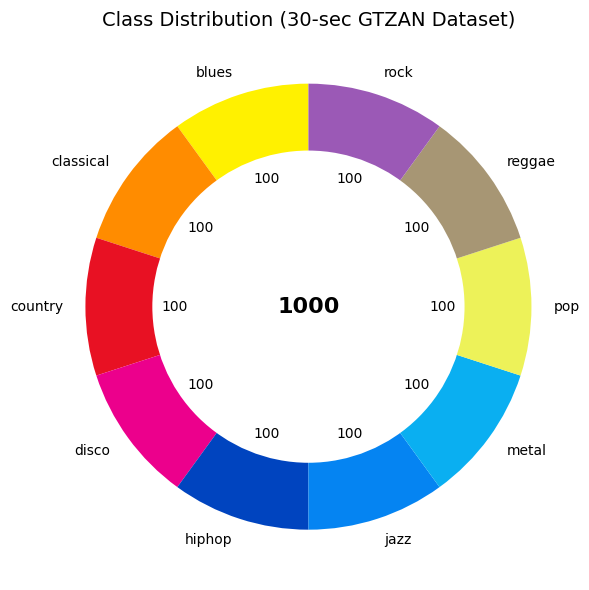

In [ ]:
#Features (30-sec dataset)
print("\nFeature Names (30-sec dataset)")
print(df_30.columns.tolist())
print("Total Columns:", len(df_30.columns))

#Class Distribution Chart (30-sec dataset)
y = df_30['label']
labels, sizes = np.unique(y, return_counts=True)
colors = [
    '#fff100','#ff8c00','#e81123','#ec008c','#0044bf',
    '#0584f2','#0aaff1','#edf259','#a79674','#9b59b6'
]

def show_count(pct):
    total = sum(sizes)
    count = int(round(pct * total / 100))
    return str(count)

fig, ax = plt.subplots(figsize=(6,6))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors[:len(labels)],
    autopct=show_count,
    startangle=90,
    textprops={'fontsize': 10}
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

total = sum(sizes)
plt.text(0, 0, f"{total}", ha='center', va='center',
         fontsize=16, fontweight='bold')

ax.axis('equal')
plt.title("Class Distribution (30-sec GTZAN Dataset)", fontsize=14)
plt.tight_layout()

plt.savefig("class_distribution_30sec.png", dpi=300, bbox_inches='tight')
plt.show()


Feature Names (3-sec dataset)
['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']
Total Columns: 60


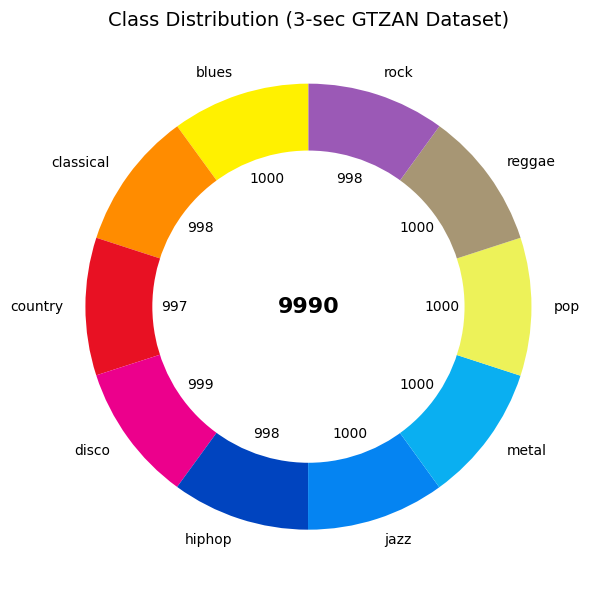

In [ ]:
#Features (3-sec dataset)
print("\nFeature Names (3-sec dataset)")
print(df_3.columns.tolist())
print("Total Columns:", len(df_3.columns))

#Class Distribution Chart (3-sec dataset)
y = df_3['label']
labels, sizes = np.unique(y, return_counts=True)

fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    sizes,
    labels=labels,
    colors=colors[:len(labels)],
    autopct=show_count,
    startangle=90,
    textprops={'fontsize': 10}
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
total = sum(sizes)
plt.text(0, 0, f"{total}", ha='center', va='center',
         fontsize=16, fontweight='bold')
ax.axis('equal')
plt.title("Class Distribution (3-sec GTZAN Dataset)", fontsize=14)
plt.tight_layout()
plt.savefig("class_distribution_3sec.png", dpi=300, bbox_inches='tight')
plt.show()

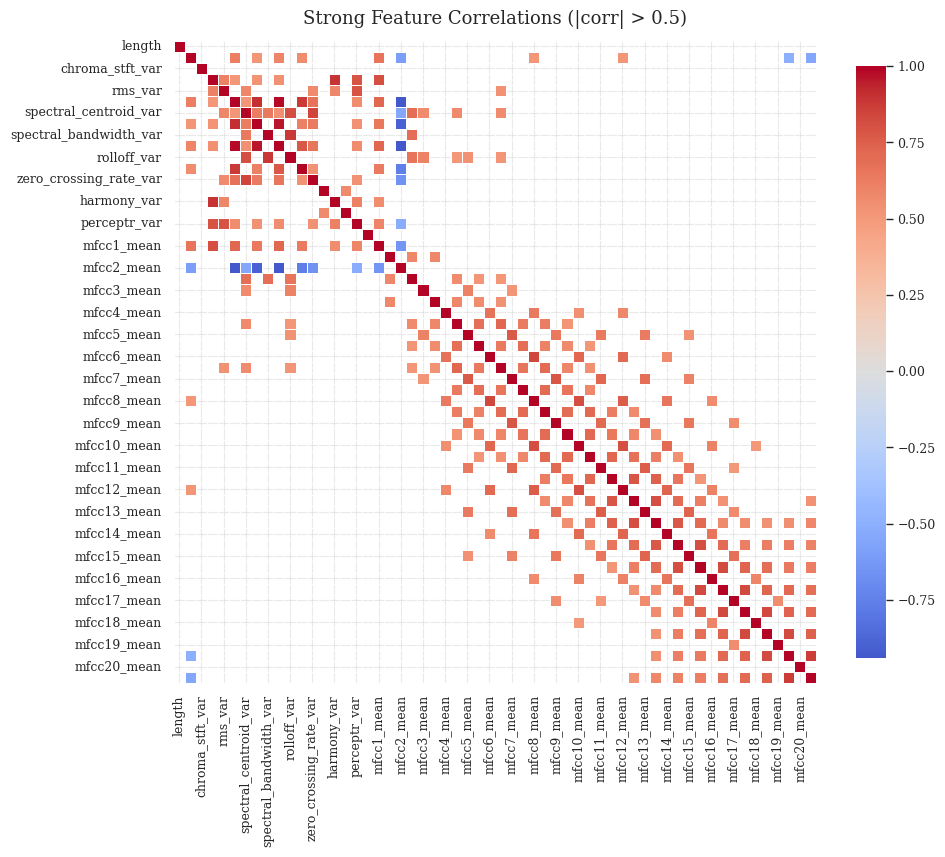

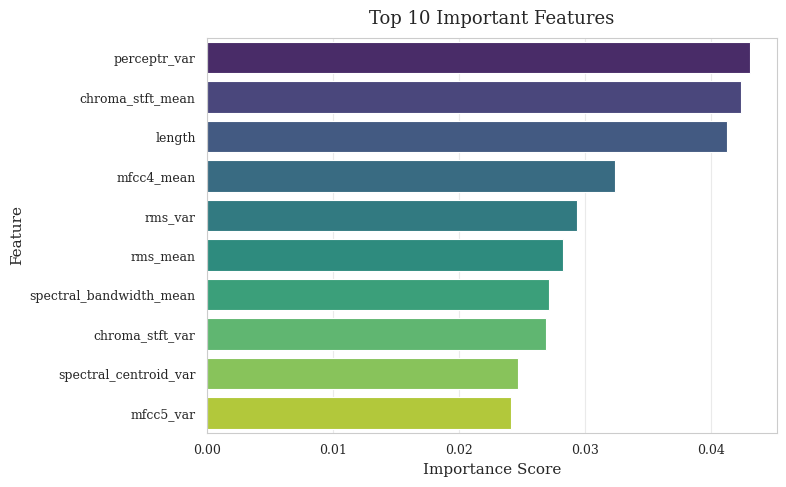

In [ ]:
#Correlation Heat Map (30-sec dataset) (only |corr| > 0.5)
sns.set_theme(style="whitegrid", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8,
    "grid.alpha": 0.4
})
X = df_30.drop(['filename', 'label'], axis=1)
y = df_30['label']

corr = X.corr()

threshold = 0.5
mask = np.abs(corr) < threshold

plt.figure(figsize=(10, 9))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Strong Feature Correlations (|corr| > 0.5)", pad=12)
plt.tight_layout()
plt.savefig("correlation.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


#Top 10 Important features using Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

top_features = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    orient='h',
    palette="viridis"
)

plt.title("Top 10 Important Features", pad=10)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### B.
Train two machine learning models of your choice (e.g., Logistic Regression, SVM, Random Forest, Gradient Boosting) on:
  a. (i) 30-second feature CSV (one sample per song)
  b. (ii) 3-second feature CSV (multiple samples per song).
#  
  For the 3-second dataset, aggregate segment predictions to obtain a final song-level label using a voting strategy (e.g., majority voting or probability averaging).

In [ ]:
#Split data for training and testing
X_30 = df_30.drop(['filename', 'label', 'length'], axis=1)
y_30 = df_30['label']

X_train_30, X_test_30, y_train_30, y_test_30, filenames_train, filenames_test = train_test_split(
    X_30, y_30, df_30['filename'],
    test_size=0.2,
    random_state=42,
    stratify=y_30
)
print("Features used for training")
print(X_30.columns.tolist())
print("Total number of features:", X_30.shape[1])
display(X_30.head())

Features used for training
['chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var']
Total number of features: 57


,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,3805.839606,9.015054e+05,...,0.752740,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035
1,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,3550.522098,2.977893e+06,...,0.927998,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282
2,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,3042.260232,7.840345e+05,...,2.451690,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025
3,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,2184.745799,1.493194e+06,...,0.780874,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339
4,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,3579.757627,1.572978e+06,...,-4.520576,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160



30-SECOND DATASET
Logistic Regression → Accuracy: 0.7100, F1: 0.7107


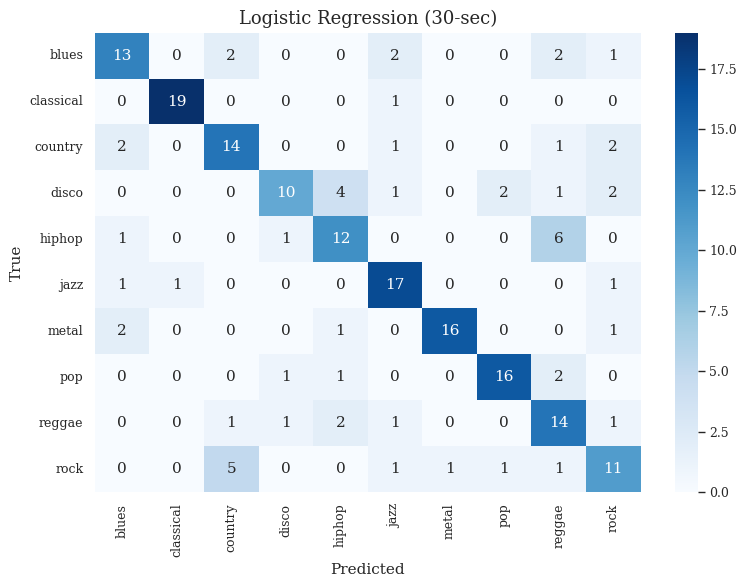

Random Forest → Accuracy: 0.6900, F1: 0.6815


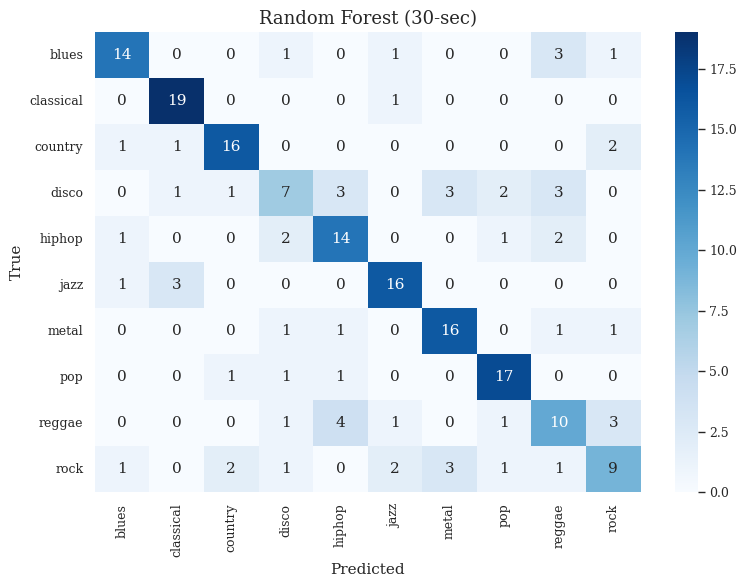

In [ ]:
#Train Models
scaler = StandardScaler()
X_train_30_scaled = scaler.fit_transform(X_train_30)
X_test_30_scaled = scaler.transform(X_test_30)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200,random_state=42)
}

results = []

print("\n30-SECOND DATASET")

for name, model in models.items():

    if name in ['Random Forest']:
        model.fit(X_train_30, y_train_30)
        y_pred = model.predict(X_test_30)
    else:
        model.fit(X_train_30_scaled, y_train_30)
        y_pred = model.predict(X_test_30_scaled)

    acc = accuracy_score(y_test_30, y_pred)
    f1 = f1_score(y_test_30, y_pred, average='macro')

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

    results.append([name, '30-sec', acc, f1])

    #Confusion Matrix
    cm = confusion_matrix(y_test_30, y_pred, labels=model.classes_)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_,
                yticklabels=model.classes_)
    plt.title(f"{name} (30-sec)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"cm_{name}_30.png")
    plt.show()



WEIGHTED HYBRID MODEL (30-sec)
Weights RF:0.5, LR:0.5 → Acc: 0.7300, F1: 0.7297
Weights RF:0.6, LR:0.4 → Acc: 0.7450, F1: 0.7449
Weights RF:0.7, LR:0.3 → Acc: 0.7400, F1: 0.7390
Weights RF:0.8, LR:0.2 → Acc: 0.7400, F1: 0.7382
Weights RF:0.9, LR:0.1 → Acc: 0.7250, F1: 0.7204

BEST WEIGHTS: (0.6, 0.4)
Best Hybrid → Accuracy: 0.7450, F1: 0.7449


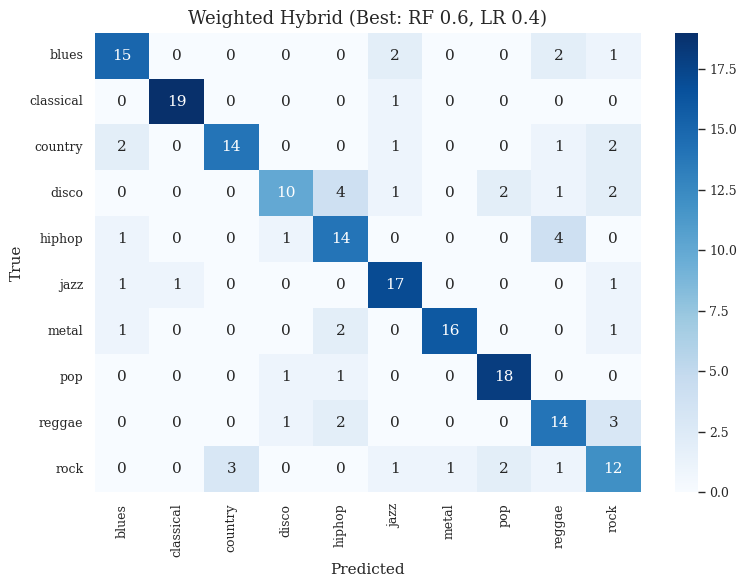

In [ ]:
#We explore a combination of both Random Forest and Logistic Regression to make a hybrid model
print("\nWEIGHTED HYBRID MODEL (30-sec)")

#Train models
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_30, y_train_30)
rf_probs = rf.predict_proba(X_test_30)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_30_scaled, y_train_30)
lr_probs = lr.predict_proba(X_test_30_scaled)

#Align RF probabilities to LR class order
rf_probs_aligned = rf_probs[:, [list(rf.classes_).index(c) for c in lr.classes_]]

#Trying multiple weights to get best results
weights = [(0.5,0.5), (0.6,0.4), (0.7,0.3), (0.8,0.2), (0.9,0.1)]

best_acc = 0
best_f1 = 0
best_w = None
best_pred_labels = None

for w_rf, w_lr in weights:

    final_probs = w_rf * rf_probs_aligned + w_lr * lr_probs
    final_pred = np.argmax(final_probs, axis=1)
    final_pred_labels = lr.classes_[final_pred]

    acc = accuracy_score(y_test_30, final_pred_labels)
    f1 = f1_score(y_test_30, final_pred_labels, average='macro')

    print(f"Weights RF:{w_rf}, LR:{w_lr} → Acc: {acc:.4f}, F1: {f1:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_f1 = f1
        best_w = (w_rf, w_lr)
        best_pred_labels = final_pred_labels

#Best result
print("\nBEST WEIGHTS:", best_w)
print(f"Best Hybrid → Accuracy: {best_acc:.4f}, F1: {best_f1:.4f}")

results.append(['Weighted Hybrid', '30-sec', best_acc, best_f1])

#Confusion Matrix for best model
labels = lr.classes_
cm = confusion_matrix(y_test_30, best_pred_labels, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title(f"Weighted Hybrid (Best: RF {best_w[0]}, LR {best_w[1]})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


 3-SECOND DATASET (Aggregated)
Logistic Regression → Accuracy: 0.7600, F1: 0.7542


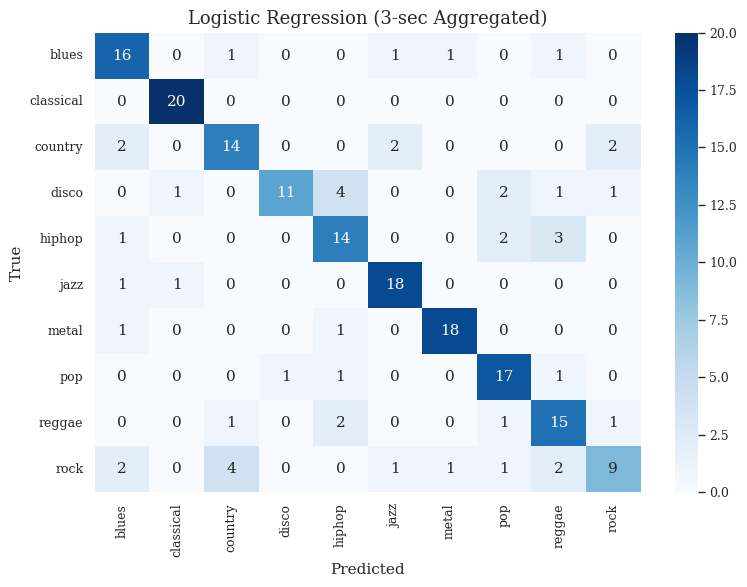

Random Forest → Accuracy: 0.7750, F1: 0.7693


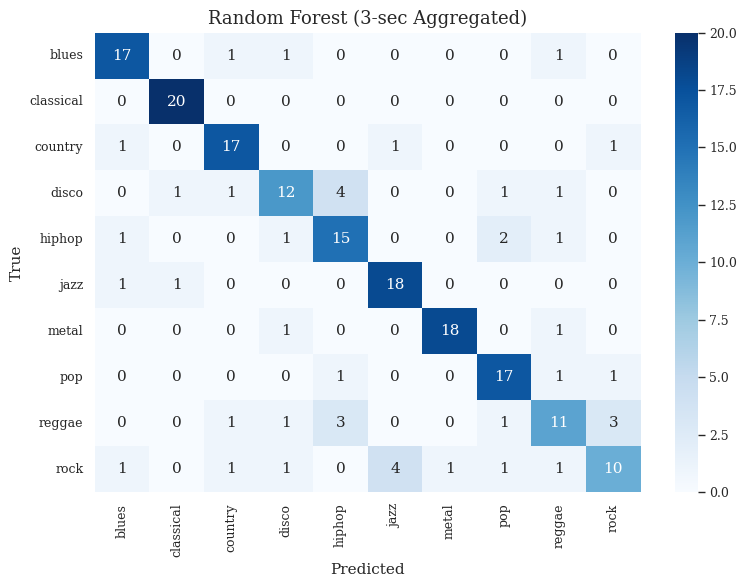

In [ ]:
#Split data for training and testing
def get_base_filename(x):
    parts = x.split('.')
    return f"{parts[0]}.{parts[1]}.wav"

df_3['base_filename'] = df_3['filename'].apply(get_base_filename)

train_3 = df_3[df_3['base_filename'].isin(filenames_train)]
test_3 = df_3[df_3['base_filename'].isin(filenames_test)]

X_train_3 = train_3.drop(['filename', 'base_filename', 'label', 'length'], axis=1)
y_train_3 = train_3['label']

X_test_3 = test_3.drop(['filename', 'base_filename', 'label', 'length'], axis=1)
y_test_3 = test_3['label']

scaler_3 = StandardScaler()
X_train_3_scaled = scaler_3.fit_transform(X_train_3)
X_test_3_scaled = scaler_3.transform(X_test_3)

#Train Model
print("\n 3-SECOND DATASET (Aggregated)")

for name, model in models.items():

    if name in ['Random Forest']:
        model.fit(X_train_3, y_train_3)
        y_pred_3 = model.predict(X_test_3)
    else:
        model.fit(X_train_3_scaled, y_train_3)
        y_pred_3 = model.predict(X_test_3_scaled)

    test_3_copy = test_3.copy()
    test_3_copy['pred'] = y_pred_3

    #Majority voting
    song_preds = test_3_copy.groupby('base_filename')['pred'].agg(lambda x: x.mode()[0])
    song_trues = test_3_copy.groupby('base_filename')['label'].first()

    aligned = pd.DataFrame({'true': song_trues, 'pred': song_preds})

    acc = accuracy_score(aligned['true'], aligned['pred'])
    f1 = f1_score(aligned['true'], aligned['pred'], average='macro')

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

    results.append([name, '3-sec', acc, f1])

    #Confusion Matrix
    cm = confusion_matrix(aligned['true'], aligned['pred'], labels=model.classes_)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_,
                yticklabels=model.classes_)
    plt.title(f"{name} (3-sec Aggregated)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"cm_{name}_3.png")
    plt.show()


 WEIGHTED HYBRID MODEL (3-sec Aggregated)
Weights RF:0.5, LR:0.5 → Acc: 0.7650, F1: 0.7612
Weights RF:0.6, LR:0.4 → Acc: 0.7800, F1: 0.7764
Weights RF:0.7, LR:0.3 → Acc: 0.8000, F1: 0.7978
Weights RF:0.8, LR:0.2 → Acc: 0.8100, F1: 0.8065
Weights RF:0.9, LR:0.1 → Acc: 0.7850, F1: 0.7801

BEST WEIGHTS: (0.8, 0.2)
Best Hybrid → Accuracy: 0.8100, F1: 0.8065


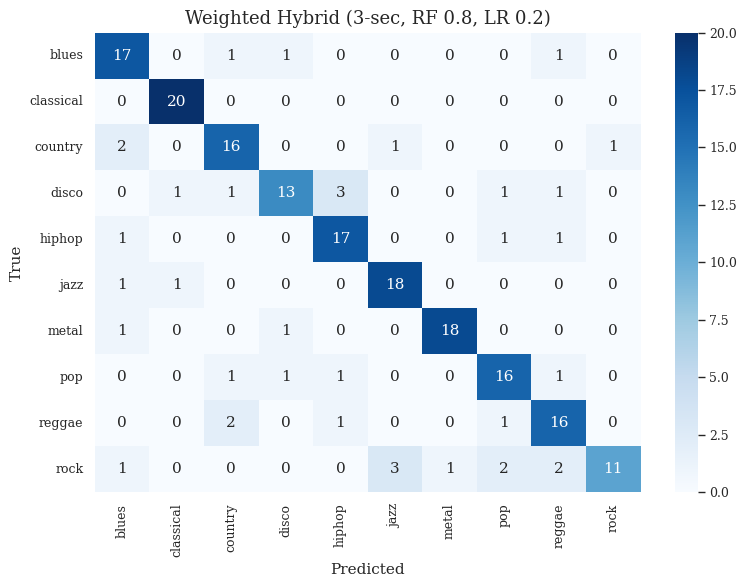

In [ ]:
print("\n WEIGHTED HYBRID MODEL (3-sec Aggregated)")

#Train models
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_3, y_train_3)
rf_probs = rf.predict_proba(X_test_3)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_3_scaled, y_train_3)
lr_probs = lr.predict_proba(X_test_3_scaled)

#Align RF probs to LR class order
rf_probs_aligned = rf_probs[:, [list(rf.classes_).index(c) for c in lr.classes_]]

#Trying multiple weights to get best results
weights = [(0.5,0.5), (0.6,0.4), (0.7,0.3), (0.8,0.2), (0.9,0.1)]

best_acc = 0
best_f1 = 0
best_w = None
best_aligned = None

for w_rf, w_lr in weights:

    final_probs = w_rf * rf_probs_aligned + w_lr * lr_probs
    final_pred = np.argmax(final_probs, axis=1)

    test_3_copy = test_3.copy()
    test_3_copy['pred'] = final_pred

    #Majority voting
    song_preds_int = test_3_copy.groupby('base_filename')['pred'].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
    )

    song_trues = test_3_copy.groupby('base_filename')['label'].first()

    class_labels = lr.classes_
    song_preds_str = class_labels[song_preds_int]

    aligned = pd.DataFrame({'true': song_trues, 'pred': song_preds_str})

    acc = accuracy_score(aligned['true'], aligned['pred'])
    f1 = f1_score(aligned['true'], aligned['pred'], average='macro')

    print(f"Weights RF:{w_rf}, LR:{w_lr} → Acc: {acc:.4f}, F1: {f1:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_f1 = f1
        best_w = (w_rf, w_lr)
        best_aligned = aligned

#Best result
print("\nBEST WEIGHTS:", best_w)
print(f"Best Hybrid → Accuracy: {best_acc:.4f}, F1: {best_f1:.4f}")

results.append(['Weighted Hybrid', '3-sec', best_acc, best_f1])

#Confusion Matrix
labels = lr.classes_
cm = confusion_matrix(best_aligned['true'], best_aligned['pred'], labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title(f"Weighted Hybrid (3-sec, RF {best_w[0]}, LR {best_w[1]})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
#Final results of Task 1
results_df = pd.DataFrame(results, columns=['Model', 'Dataset', 'Accuracy', 'Macro F1'])
results_df.to_csv("final_results.csv", index=False)

print("\nFinal Results:")
print(results_df)


Final Results:
                 Model Dataset  Accuracy  Macro F1
0  Logistic Regression  30-sec     0.710  0.710735
1        Random Forest  30-sec     0.690  0.681532
2      Weighted Hybrid  30-sec     0.745  0.744928
3  Logistic Regression   3-sec     0.760  0.754170
4        Random Forest   3-sec     0.775  0.769307
5      Weighted Hybrid   3-sec     0.810  0.806542


## Task 2: Dimensionality Reduction using PCA
### A. and B.
Select the best-performing model from Q1 and apply Principal Component Analysis (PCA) to the feature set prior to training.

In [ ]:
#Applying PCA to our previous models
def task2(df_3, filenames_train, filenames_test):
    print("=== Task 2: Dimensionality Reduction using PCA ===")

    df_30 = pd.read_csv(FEATURES_30_SEC)
    # 30-SEC PCA
    X_30 = df_30.drop(['filename', 'label', 'length'], axis=1)
    y_30 = df_30['label']

    X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
        X_30, y_30, test_size=0.2, random_state=42, stratify=y_30
    )

    scaler = StandardScaler()
    X_train_30_scaled = scaler.fit_transform(X_train_30)
    X_test_30_scaled = scaler.transform(X_test_30)

    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train_30_scaled)
    X_test_pca = pca.transform(X_test_30_scaled)

    print(f"\n30-sec PCA")
    print(f"Original number of features: {X_train_30_scaled.shape[1]}")
    print(f"Number of features after PCA (95% variance): {X_train_pca.shape[1]}")

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_pca, y_train_30)
    y_pred = model.predict(X_test_pca)

    acc_30 = accuracy_score(y_test_30, y_pred)
    f1_30 = f1_score(y_test_30, y_pred, average='macro')

    print(f"Random Forest (PCA 30-sec) -> Accuracy: {acc_30:.4f}, Macro F1: {f1_30:.4f}")
    # 3-SEC PCA
    def get_base_filename(x):
        parts = x.split('.')
        return f"{parts[0]}.{parts[1]}.wav"

    df_3['base_filename'] = df_3['filename'].apply(get_base_filename)

    train_3 = df_3[df_3['base_filename'].isin(filenames_train)]
    test_3 = df_3[df_3['base_filename'].isin(filenames_test)]

    X_train_3 = train_3.drop(['filename', 'base_filename', 'label', 'length'], axis=1)
    y_train_3 = train_3['label']

    X_test_3 = test_3.drop(['filename', 'base_filename', 'label', 'length'], axis=1)
    y_test_3 = test_3['label']

    scaler_3 = StandardScaler()
    X_train_3_scaled = scaler_3.fit_transform(X_train_3)
    X_test_3_scaled = scaler_3.transform(X_test_3)

    pca_3 = PCA(n_components=0.95, random_state=42)
    X_train_3_pca = pca_3.fit_transform(X_train_3_scaled)
    X_test_3_pca = pca_3.transform(X_test_3_scaled)

    print(f"\n3-sec PCA")
    print(f"Original number of features: {X_train_3_scaled.shape[1]}")
    print(f"Number of features after PCA (95% variance): {X_train_3_pca.shape[1]}")

    model.fit(X_train_3_pca, y_train_3)
    y_pred_3 = model.predict(X_test_3_pca)

    #Majority voting
    test_3_copy = test_3.copy()
    test_3_copy['pred'] = y_pred_3

    song_preds = test_3_copy.groupby('base_filename')['pred'].agg(lambda x: x.mode()[0])
    song_trues = test_3_copy.groupby('base_filename')['label'].first()

    aligned = pd.DataFrame({'true': song_trues, 'pred': song_preds})

    acc_3 = accuracy_score(aligned['true'], aligned['pred'])
    f1_3 = f1_score(aligned['true'], aligned['pred'], average='macro')

    print(f"Random Forest (PCA 3-sec) -> Accuracy: {acc_3:.4f}, Macro F1: {f1_3:.4f}")

    return acc_30, f1_30, acc_3, f1_3
pca_acc_30, pca_f1_30, pca_acc_3, pca_f1_3 = task2(df_3, filenames_train, filenames_test)

=== Task 2: Dimensionality Reduction using PCA ===

30-sec PCA
Original number of features: 57
Number of features after PCA (95% variance): 33
Random Forest (PCA 30-sec) -> Accuracy: 0.7200, Macro F1: 0.7187

3-sec PCA
Original number of features: 57
Number of features after PCA (95% variance): 39
Random Forest (PCA 3-sec) -> Accuracy: 0.7200, Macro F1: 0.7157


In [ ]:
#Add PCA results into results list
results.append(['Random Forest (PCA)', '30-sec', pca_acc_30, pca_f1_30])
results.append(['Random Forest (PCA)', '3-sec', pca_acc_3, pca_f1_3])
results_df = pd.DataFrame(results, columns=['Model', 'Dataset', 'Accuracy', 'Macro F1'])
results_df.to_csv("final_results.csv", index=False)

print("\nFinal Results:")
print(results_df)


Final Results:
                 Model Dataset  Accuracy  Macro F1
0  Logistic Regression  30-sec     0.710  0.710735
1        Random Forest  30-sec     0.690  0.681532
2      Weighted Hybrid  30-sec     0.745  0.744928
3  Logistic Regression   3-sec     0.760  0.754170
4        Random Forest   3-sec     0.775  0.769307
5      Weighted Hybrid   3-sec     0.810  0.806542
6  Random Forest (PCA)  30-sec     0.720  0.718695
7  Random Forest (PCA)   3-sec     0.720  0.715716


## Visualizing PCA Projection of Genres

To understand the separation of genres in the feature space, we'll perform PCA to reduce the dimensionality to 2 components and visualize the projection.

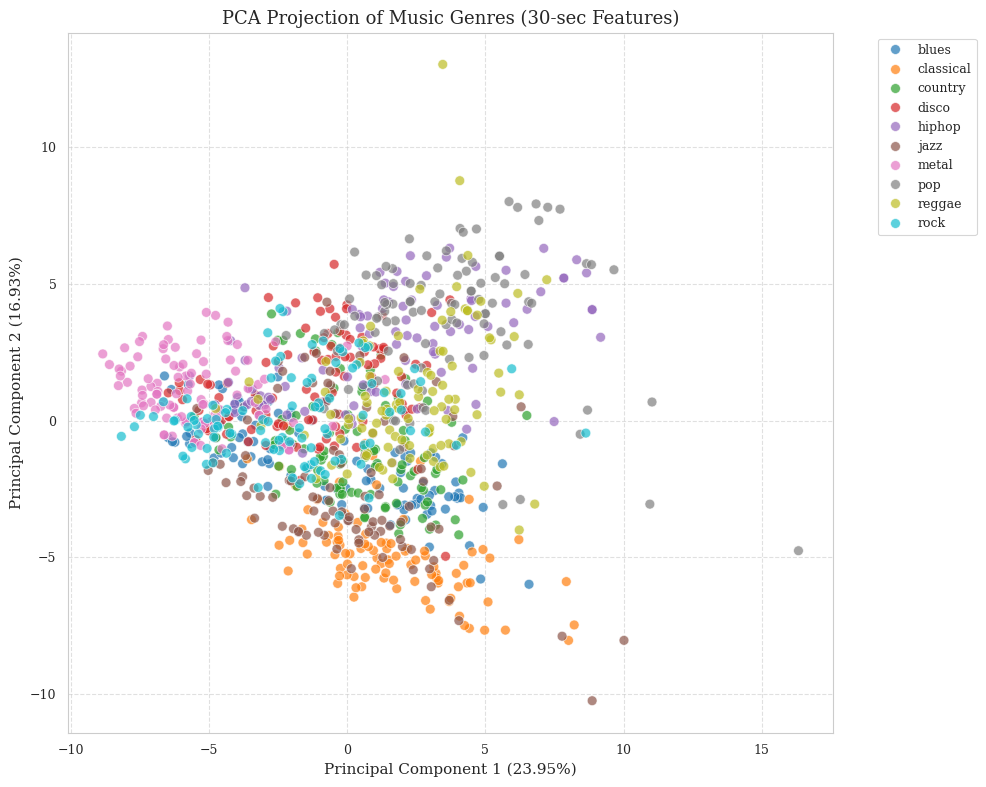

In [ ]:
X = df_30.drop(['filename', 'label', 'length'], axis=1)
y = df_30['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#2 components PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Genre'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Genre',
    data=pca_df,
    palette='tab10',
    s=50,
    alpha=0.7
)
plt.title('PCA Projection of Music Genres (30-sec Features)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

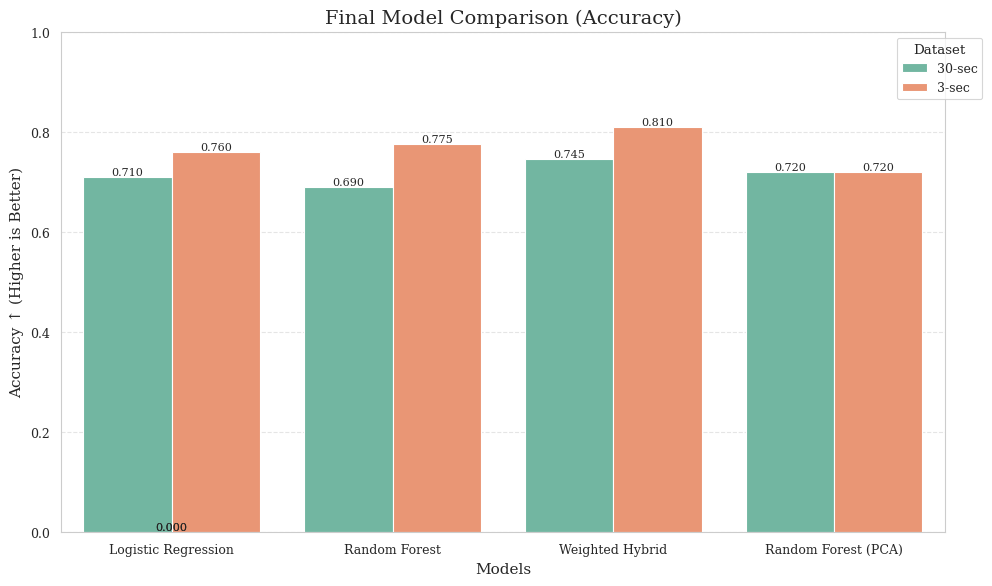

In [ ]:
#Final Results for Task 2
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x='Model',
    y='Accuracy',
    hue='Dataset',
    data=results_df,
    palette='Set2'
)

for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{height:.3f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8)

plt.title("Final Model Comparison (Accuracy)", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy ↑ (Higher is Better)")
plt.ylim(0, 1)
plt.legend(title="Dataset", bbox_to_anchor=(1.05,1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

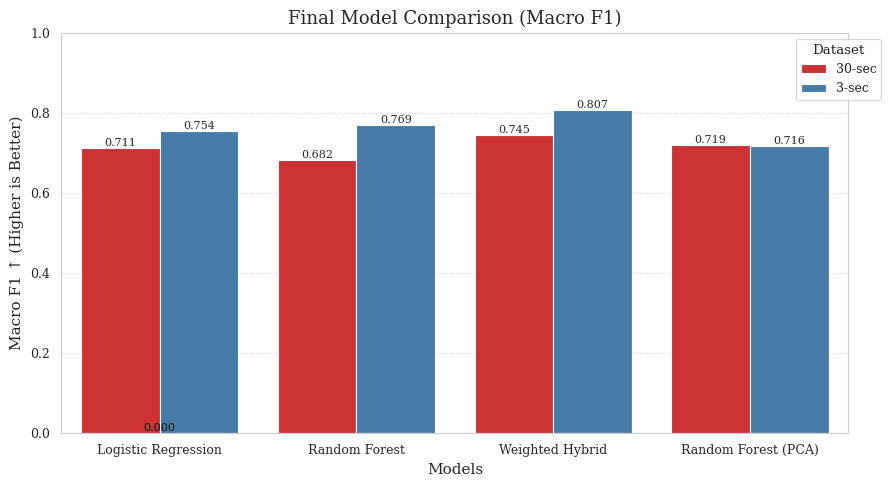

In [ ]:
#Final results for Task 2

plt.figure(figsize=(9,5))
ax = sns.barplot(
    x='Model',
    y='Macro F1',
    hue='Dataset',
    data=results_df,
    palette='Set1'
)

for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{height:.3f}',
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=8)

plt.title("Final Model Comparison (Macro F1)", fontsize=13)
plt.xlabel("Models")
plt.ylabel("Macro F1 ↑ (Higher is Better)")
plt.ylim(0, 1)
plt.legend(title="Dataset", bbox_to_anchor=(1.05,1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Task 3: Spectrogram-based Deep Learning
### A.
 Design and train a 2D Convolutional Neural Network (CNN) for music genre classification. Choose appropriate hyperparameters (learning rate, batch size, number of layers, etc.).  

Using device: cuda

 Starting Training...
Epoch [1/30] - Loss: 3.3390 | Val Acc: 0.2267
Epoch [2/30] - Loss: 1.8881 | Val Acc: 0.3800
Epoch [3/30] - Loss: 1.7484 | Val Acc: 0.3600
Epoch [4/30] - Loss: 1.5979 | Val Acc: 0.4800
Epoch [5/30] - Loss: 1.4629 | Val Acc: 0.4000
Epoch [6/30] - Loss: 1.4281 | Val Acc: 0.4733
Epoch [7/30] - Loss: 1.3194 | Val Acc: 0.4400
Epoch [8/30] - Loss: 1.2990 | Val Acc: 0.5267
Epoch [9/30] - Loss: 1.2463 | Val Acc: 0.5067
Epoch [10/30] - Loss: 1.0878 | Val Acc: 0.5533
Epoch [11/30] - Loss: 1.0871 | Val Acc: 0.5200
Epoch [12/30] - Loss: 0.9840 | Val Acc: 0.5533
Epoch [13/30] - Loss: 0.9665 | Val Acc: 0.4867
Epoch [14/30] - Loss: 0.9821 | Val Acc: 0.4800
Epoch [15/30] - Loss: 0.9378 | Val Acc: 0.5800
Epoch [16/30] - Loss: 0.8831 | Val Acc: 0.5867
Epoch [17/30] - Loss: 0.8488 | Val Acc: 0.5600
Epoch [18/30] - Loss: 0.7595 | Val Acc: 0.4800
Epoch [19/30] - Loss: 0.7154 | Val Acc: 0.4467
Epoch [20/30] - Loss: 0.6996 | Val Acc: 0.5733
Epoch [21/30] - Loss: 0.669

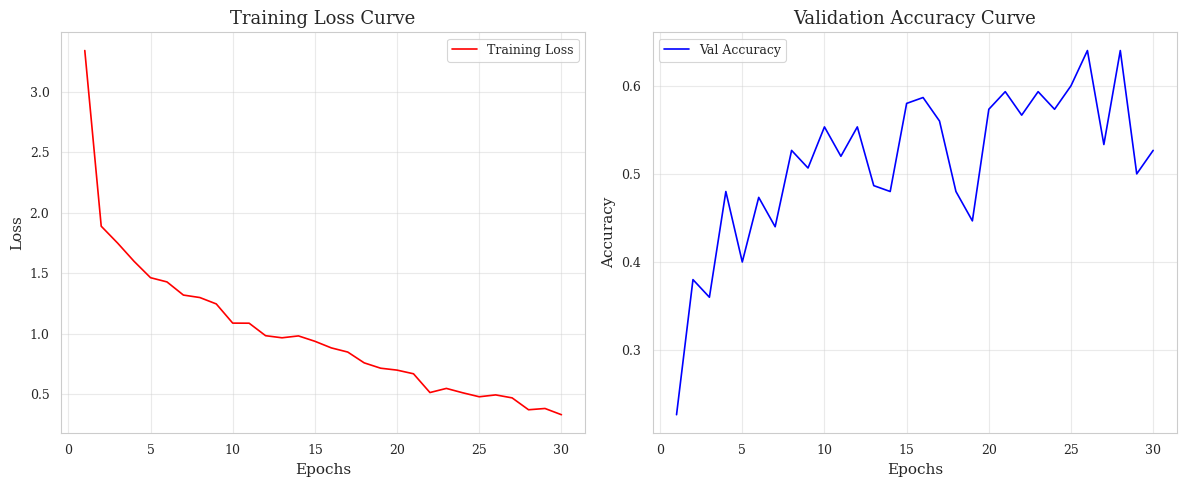


 Evaluating Best Model on Test Set...

 Final Test Accuracy: 0.6800

Classification Report:
              precision    recall  f1-score   support

       blues       0.80      0.50      0.62        16
   classical       1.00      0.64      0.78        11
     country       0.57      0.63      0.60        19
       disco       0.74      0.67      0.70        21
      hiphop       0.71      0.77      0.74        13
        jazz       0.52      0.92      0.67        12
       metal       1.00      1.00      1.00        12
         pop       0.82      0.82      0.82        17
      reggae       0.73      0.53      0.62        15
        rock       0.33      0.43      0.38        14

    accuracy                           0.68       150
   macro avg       0.72      0.69      0.69       150
weighted avg       0.72      0.68      0.68       150



<Figure size 1000x800 with 0 Axes>

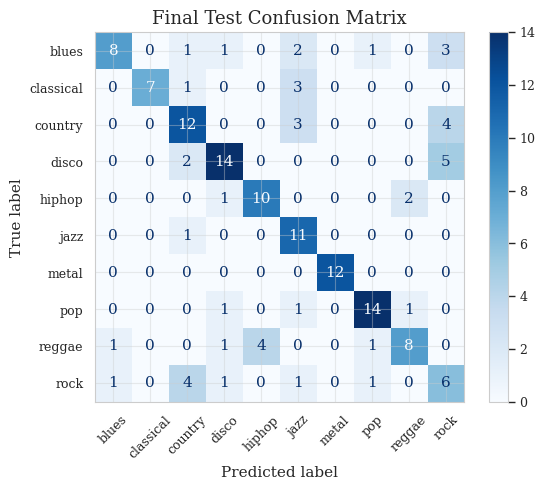

In [ ]:
torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

#Hyperparameters

param_sets = [
    #{"lr": 0.001, "batch_size": 32},
    #{"lr": 0.0005, "batch_size": 32},
    #{"lr": 0.001, "batch_size": 64},
    #{"lr": 0.0005, "batch_size": 64},
    #{"lr": 0.0001, "batch_size": 32}
]

num_epochs = 30
IMG_DIR = "Data/images_original"
BATCH_SIZE = 32
LR = 0.0005
EPOCHS = 30

#CNN architecture
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)
        )
        # 128x128 -> after 4 MaxPools (2x2) -> 8x8 spatial size
        self.classifier = nn.Sequential(
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

#Data preparation
data_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=IMG_DIR)
total_size = len(full_dataset)
indices = torch.randperm(total_size, generator=torch.Generator().manual_seed(42))

# Split dataset 70% Train, 15% Val, 15% Test
train_split = int(0.7 * total_size)
val_split = int(0.85 * total_size)

train_idx = indices[:train_split]
val_idx = indices[train_split:val_split]
test_idx = indices[val_split:]

train_loader = DataLoader(Subset(datasets.ImageFolder(root=IMG_DIR, transform=data_transforms), train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Subset(datasets.ImageFolder(root=IMG_DIR, transform=data_transforms), val_idx), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(Subset(datasets.ImageFolder(root=IMG_DIR, transform=data_transforms), test_idx), batch_size=BATCH_SIZE, shuffle=False)

#Train CNN
model = ImprovedCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_accuracies = []
best_acc = 0

print("\n Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    #Validation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            outputs = model(imgs.to(device))
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(lbls.numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_accuracies.append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_cnn_model.pth")

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")

#Results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Training Loss', color='red')
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), val_accuracies, label='Val Accuracy', color='blue')
plt.title('Validation Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#Best Model
print("\n Evaluating Best Model on Test Set...")
model.load_state_dict(torch.load("best_cnn_model.pth"))
model.eval()

test_preds, true_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        outputs = model(imgs.to(device))
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        true_labels.extend(lbls.numpy())

final_test_acc = accuracy_score(true_labels, test_preds)
print(f"\n Final Test Accuracy: {final_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(true_labels, test_preds, target_names=full_dataset.classes))

#Confusion Matrix
cm = confusion_matrix(true_labels, test_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Final Test Confusion Matrix")
plt.show()

Using device: cuda
Epoch [1/20] Loss: 1.8812 | Val Acc: 0.5436 | LR: 0.000100
Epoch [2/20] Loss: 1.1311 | Val Acc: 0.6309 | LR: 0.000100
Epoch [3/20] Loss: 0.8147 | Val Acc: 0.6846 | LR: 0.000100
Epoch [4/20] Loss: 0.5218 | Val Acc: 0.7047 | LR: 0.000100
Epoch [5/20] Loss: 0.3728 | Val Acc: 0.7315 | LR: 0.000100
Epoch [6/20] Loss: 0.2280 | Val Acc: 0.7651 | LR: 0.000100
Epoch [7/20] Loss: 0.1642 | Val Acc: 0.7517 | LR: 0.000100
Epoch [8/20] Loss: 0.1243 | Val Acc: 0.7517 | LR: 0.000100
Epoch [9/20] Loss: 0.1145 | Val Acc: 0.6913 | LR: 0.000100
Epoch [10/20] Loss: 0.0765 | Val Acc: 0.7450 | LR: 0.000100
Epoch [11/20] Loss: 0.0479 | Val Acc: 0.7651 | LR: 0.000050
Epoch [12/20] Loss: 0.0479 | Val Acc: 0.7584 | LR: 0.000050
Epoch [13/20] Loss: 0.0332 | Val Acc: 0.7718 | LR: 0.000050
Epoch [14/20] Loss: 0.0311 | Val Acc: 0.7718 | LR: 0.000050
Epoch [15/20] Loss: 0.0347 | Val Acc: 0.7584 | LR: 0.000050
Epoch [16/20] Loss: 0.0206 | Val Acc: 0.7450 | LR: 0.000050
Epoch [17/20] Loss: 0.0188 | V

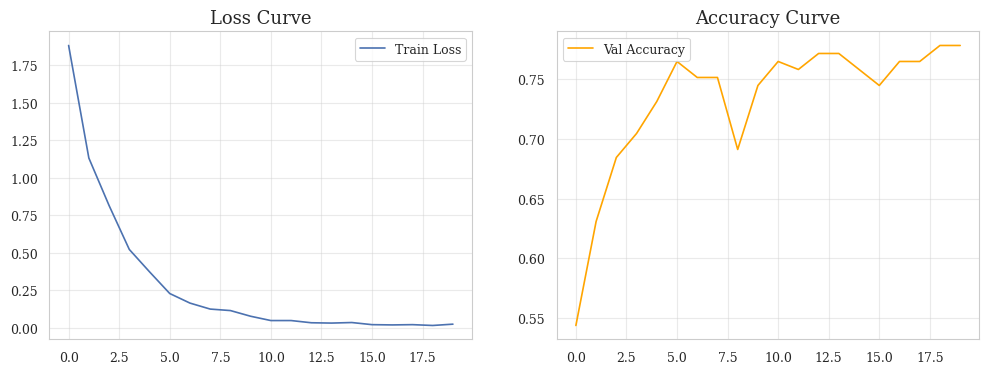

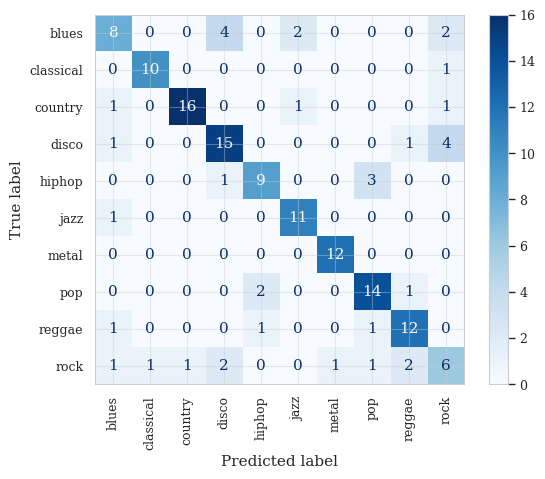

In [ ]:
# We explore the idea of ResNet18, pre-trained on ImageNet, and utilize its learned feature extractors (edges, textures, shapes) which generalize well to spectrograms.

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

IMG_DIR = "Data/images_original"
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 20

# ResNet
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=IMG_DIR)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

indices = torch.randperm(total_size, generator=torch.Generator().manual_seed(42))

train_dataset = Subset(datasets.ImageFolder(root=IMG_DIR, transform=train_transform), indices[:train_size])
val_dataset = Subset(datasets.ImageFolder(root=IMG_DIR, transform=test_transform), indices[train_size:train_size+val_size])
test_dataset = Subset(datasets.ImageFolder(root=IMG_DIR, transform=test_transform), indices[train_size+val_size:])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


def get_model(num_classes):

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_ftrs, num_classes)
    )
    return model.to(device)

model = get_model(len(full_dataset.classes))

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
#Scheduler reduces Learning Rate when validation accuracy stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

best_val_acc = 0.0
history = {"train_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    history["train_loss"].append(epoch_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    scheduler.step(val_acc) # Adjust Learning Rate based on validation accuracy

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet_model.pth")

print("\nFinal Testing...")
model.load_state_dict(torch.load("best_resnet_model.pth"))
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.numpy())

print("\nFinal Test Accuracy:", accuracy_score(test_labels, test_preds))
print("\nClassification Report:\n", classification_report(test_labels, test_preds, target_names=full_dataset.classes))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label='Train Loss')
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_acc"], label='Val Accuracy', color='orange')
plt.title("Accuracy Curve")
plt.legend()
plt.show()

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
disp.plot(cmap='Blues', xticks_rotation=90)
plt.show()

 Starting Hybrid Training on cuda...
Epoch [1/25] Loss: 2.2173 | Val Acc: 0.4564 | LR: 0.000100
Epoch [2/25] Loss: 1.9662 | Val Acc: 0.5034 | LR: 0.000100
Epoch [3/25] Loss: 1.7068 | Val Acc: 0.5839 | LR: 0.000100
Epoch [4/25] Loss: 1.4633 | Val Acc: 0.6040 | LR: 0.000100
Epoch [5/25] Loss: 1.2687 | Val Acc: 0.5906 | LR: 0.000100
Epoch [6/25] Loss: 1.0905 | Val Acc: 0.6846 | LR: 0.000100
Epoch [7/25] Loss: 0.9282 | Val Acc: 0.6577 | LR: 0.000100
Epoch [8/25] Loss: 0.8301 | Val Acc: 0.7181 | LR: 0.000100
Epoch [9/25] Loss: 0.7656 | Val Acc: 0.7517 | LR: 0.000100
Epoch [10/25] Loss: 0.7024 | Val Acc: 0.6980 | LR: 0.000100
Epoch [11/25] Loss: 0.6683 | Val Acc: 0.6846 | LR: 0.000100
Epoch [12/25] Loss: 0.6514 | Val Acc: 0.7047 | LR: 0.000100
Epoch [13/25] Loss: 0.6145 | Val Acc: 0.7114 | LR: 0.000100
Epoch [14/25] Loss: 0.6242 | Val Acc: 0.7315 | LR: 0.000050
Epoch [15/25] Loss: 0.5999 | Val Acc: 0.7315 | LR: 0.000050
Epoch [16/25] Loss: 0.5918 | Val Acc: 0.7450 | LR: 0.000050
Epoch [17/25

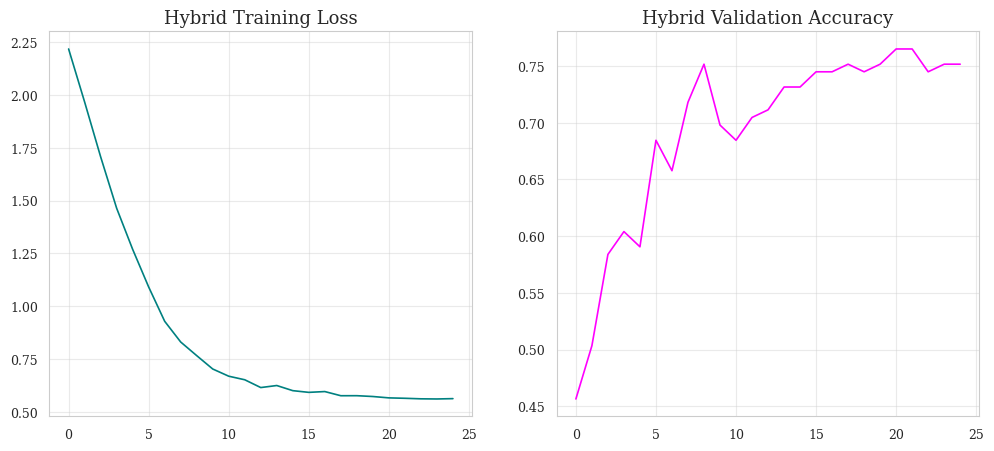

<Figure size 1000x800 with 0 Axes>

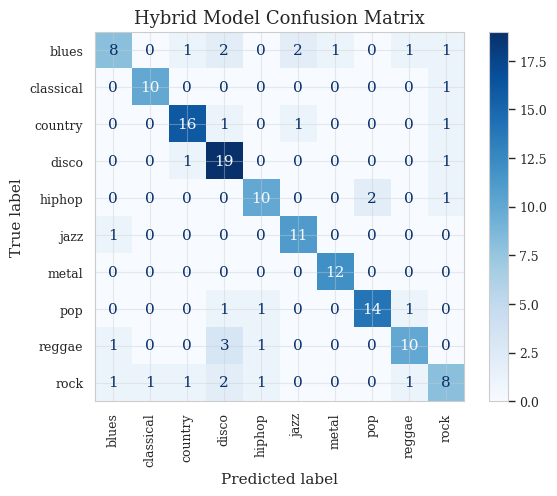

In [ ]:
# We explore an ensemble method of CNN + LSTM to capture both spatial features and temporal dependencies
class AudioEnsemble(nn.Module):
    def __init__(self, num_classes):
        super(AudioEnsemble, self).__init__()

        # CNN Branch (Spatial)
        # Using ResNet18 but removing the final FC layer
        base_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn_branch = nn.Sequential(*list(base_resnet.children())[:-1])
        self.cnn_fc = nn.Linear(base_resnet.fc.in_features, 256)

        # LSTM Branch (Temporal)
        self.lstm = nn.LSTM(input_size=224, hidden_size=128, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=0.3)
        self.lstm_fc = nn.Linear(128 * 2, 256) # *2 for bidirectional

        # Combined Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256 + 256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # CNN Path
        cnn_feat = self.cnn_branch(x)
        cnn_feat = torch.flatten(cnn_feat, 1)
        cnn_out = F.relu(self.cnn_fc(cnn_feat))

        # LSTM Path
        x_seq = x.mean(dim=1)
        lstm_out, _ = self.lstm(x_seq)
        lstm_out = lstm_out[:, -1, :]
        lstm_out = F.relu(self.lstm_fc(lstm_out))

        combined = torch.cat((cnn_out, lstm_out), dim=1)
        return self.classifier(combined)

# Initialize model
model = AudioEnsemble(len(full_dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

EPOCHS = 25
history = {"train_loss": [], "val_acc": []}
best_val_acc = 0.0

print(f" Starting Hybrid Training on {device}...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            out = model(imgs.to(device))
            val_preds.extend(out.argmax(1).cpu().numpy())
            val_labels.extend(lbls.numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    history["train_loss"].append(avg_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_hybrid_ensemble.pth")


print("\n Final Testing on Best Hybrid Model...")
model.load_state_dict(torch.load("best_hybrid_ensemble.pth"))
model.eval()

test_preds, test_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model(imgs.to(device))
        test_preds.extend(out.argmax(1).cpu().numpy())
        test_labels.extend(lbls.numpy())

test_acc = accuracy_score(test_labels, test_preds)
print(f"\n FINAL TEST ACCURACY: {test_acc:.4f}")
print("\nClassification Report:\n", classification_report(test_labels, test_preds, target_names=full_dataset.classes))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label='Train Loss', color='teal')
plt.title("Hybrid Training Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history["val_acc"], label='Val Accuracy', color='magenta')
plt.title("Hybrid Validation Accuracy")
plt.grid(True)
plt.savefig("hybrid_performance.png")

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Hybrid Model Confusion Matrix")
plt.savefig("hybrid_cm.png")

## Task 4: Pretrained Audio Representation + Classifier (Wav2Vec2 & MERT)

### A.
 a. Use the raw waveform or spectrogram as input to a pretrained music-audio representation model.

 b. Extract embeddings for each track.

 c. Train a small MLP classifier (2–3 fully connected layers) on top of these embeddings to predict the music genre.

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...


Extracting Validation embeddings...


Extracting embeddings: 100%|██████████| 149/149 [00:07<00:00, 20.15it/s]



Extracting Test embeddings...


Extracting embeddings: 100%|██████████| 151/151 [00:07<00:00, 19.97it/s]


Wav2Vec2 Pretrained Audio Representation + Classifier (MLP Training)
Epoch [1/25] | Loss: 2.3046 | Val Acc: 0.1208
Epoch [2/25] | Loss: 2.2879 | Val Acc: 0.1477
Epoch [3/25] | Loss: 2.2709 | Val Acc: 0.1812
Epoch [4/25] | Loss: 2.2510 | Val Acc: 0.1812
Epoch [5/25] | Loss: 2.2302 | Val Acc: 0.1812
Epoch [6/25] | Loss: 2.2009 | Val Acc: 0.1745
Epoch [7/25] | Loss: 2.1693 | Val Acc: 0.2215
Epoch [8/25] | Loss: 2.1345 | Val Acc: 0.2282
Epoch [9/25] | Loss: 2.0966 | Val Acc: 0.2282
Epoch [10/25] | Loss: 2.0580 | Val Acc: 0.2416
Epoch [11/25] | Loss: 2.0039 | Val Acc: 0.2349
Epoch [12/25] | Loss: 1.9617 | Val Acc: 0.2416
Epoch [13/25] | Loss: 1.9071 | Val Acc: 0.2752
Epoch [14/25] | Loss: 1.8626 | Val Acc: 0.3221
Epoch [15/25] | Loss: 1.8106 | Val Acc: 0.3423
Epoch [16/25] | Loss: 1.7675 | Val Acc: 0.3758
Epoch [17/25] | Loss: 1.7203 | Val Acc: 0.3893
Epoch [18/25] | Loss: 1.6787 | Val Acc: 0.4161
Epoch [19/25] | Loss: 1.6370 | Val Acc: 0.4295
Epoch [20/25] | Loss: 1.6075 | Val Acc: 0.4631


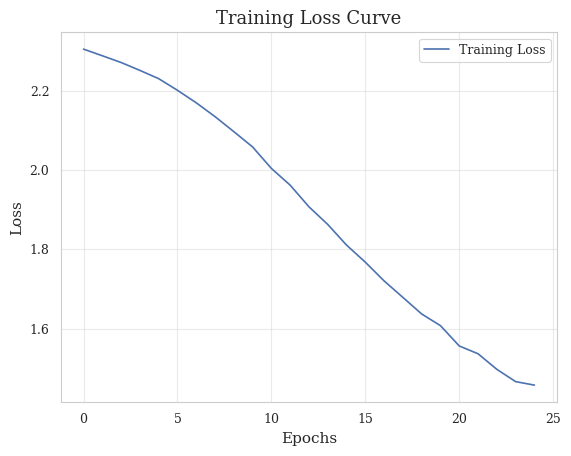


--- Final Evaluation ---
Test Accuracy: 0.4768
Macro F1-score: 0.4642


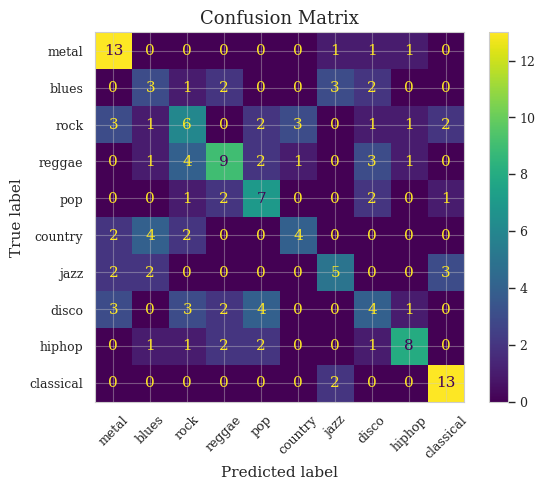

In [ ]:
AUDIO_DIR = "/content/Data/genres_original"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
pretrained_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device)
pretrained_model.eval()

genres = [g for g in os.listdir(AUDIO_DIR) if os.path.isdir(os.path.join(AUDIO_DIR, g))]
genre_to_id = {g: i for i, g in enumerate(genres)}

class AudioDataset(Dataset):
    def __init__(self, audio_dir, genre_to_id, genres):
        self.filepaths = []
        self.labels = []
        self.genre_to_id = genre_to_id
        self.genres = genres

        for genre in genres:
            g_dir = os.path.join(audio_dir, genre)
            for f in os.listdir(g_dir):
                if f.endswith(".wav") and f != "jazz.00054.wav":
                    self.filepaths.append(os.path.join(g_dir, f))
                    self.labels.append(self.genre_to_id[genre])

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(path)

        if sr != 16000:
            waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)

        if waveform.size(1) > 48000:
            waveform = waveform[:, :48000]
        else:
            pad = torch.zeros(1, 48000 - waveform.size(1))
            waveform = torch.cat([waveform, pad], dim=1)

        waveform = waveform.mean(dim=0)

        input_values = processor(
            waveform.numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        ).input_values.squeeze(0).to(device)

        return input_values, label

dataset = AudioDataset(AUDIO_DIR, genre_to_id, genres)
total = len(dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

def extract_embeddings(ds, processor, pretrained_model, device):
    X, y = [], []
    original_dataset_filepaths = ds.dataset.filepaths
    subset_filepaths = [original_dataset_filepaths[i] for i in ds.indices]

    with torch.no_grad():
        for i in tqdm(range(len(ds)), desc="Extracting embeddings"):
            inp, lbl = ds[i]
            inp = inp.unsqueeze(0)

            outputs = pretrained_model(inp)
            emb = outputs.last_hidden_state.mean(dim=1).squeeze().cpu()

            X.append(emb)
            y.append(lbl)
    return torch.stack(X), torch.tensor(y), subset_filepaths

print("\nExtracting Train embeddings...")
X_train, y_train, train_filepaths = extract_embeddings(train_ds, processor, pretrained_model, device)

print("\nExtracting Validation embeddings...")
X_val, y_val, val_filepaths = extract_embeddings(val_ds, processor, pretrained_model, device)

print("\nExtracting Test embeddings...")
X_test, y_test, test_filepaths = extract_embeddings(test_ds, processor, pretrained_model, device)

X_train, y_train = X_train.to(device), y_train.to(device)
X_val, y_val = X_val.to(device), y_val.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

def task4_wav2vec2_mlp_training(X_train, y_train, X_val, y_val, X_test, y_test, genres):
    print("Wav2Vec2 Pretrained Audio Representation + Classifier (MLP Training)")

    class MLP(nn.Module):
        def __init__(self, input_size, num_classes):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_size, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, num_classes)
            )

        def forward(self, x):
            return self.net(x)

    model = MLP(X_train.shape[1], len(genres)).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_accuracies = []

    epochs = 25

    for epoch in range(epochs):
        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_out = model(X_val)
            _, val_preds = torch.max(val_out, 1)

            val_acc = accuracy_score(y_val.cpu(), val_preds.cpu())
            val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | Val Acc: {val_acc:.4f}")

    #Loss plot
    plt.figure()
    plt.plot(train_losses, label="Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.legend()
    plt.show()

    #Results
    model.eval()
    with torch.no_grad():
        test_out = model(X_test)
        _, preds = torch.max(test_out, 1)

        acc = accuracy_score(y_test.cpu(), preds.cpu())
        f1 = f1_score(y_test.cpu(), preds.cpu(), average='macro')

    print("\nFinal Evaluation")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Macro F1-score: {f1:.4f}")

    #Confusion Matrix
    cm = confusion_matrix(y_test.cpu(), preds.cpu())

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genres)
    disp.plot(xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

task4_wav2vec2_mlp_training(X_train, y_train, X_val, y_val, X_test, y_test, genres)

preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The image processor of type `Wav2Vec2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


modeling_MERT.py: 0.00B [00:00, ?B/s]

...

Epoch 8 | Loss: 0.2824 | Val Acc: 0.8133


Epoch 9: 100%|██████████| 175/175 [01:52<00:00,  1.56it/s]


Epoch 9 | Loss: 0.1439 | Val Acc: 0.7933


Epoch 10: 100%|██████████| 175/175 [01:52<00:00,  1.56it/s]


Epoch 10 | Loss: 0.1342 | Val Acc: 0.8200

Test Accuracy: 0.8133333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        16
           1       0.87      0.93      0.90        14
           2       0.71      0.67      0.69        18
           3       0.89      0.73      0.80        11
           4       1.00      0.60      0.75        10
           5       0.90      1.00      0.95        19
           6       0.93      0.78      0.85        18
           7       0.75      0.94      0.83        16
           8       0.93      1.00      0.97        14
           9       0.50      0.57      0.53        14

    accuracy                           0.81       150
   macro avg       0.83      0.80      0.81       150
weighted avg       0.82      0.81      0.81       150



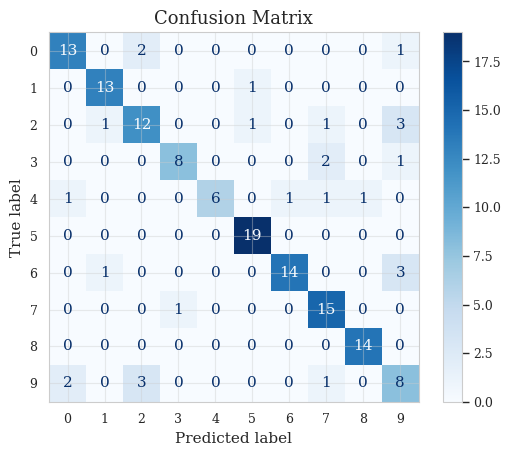


Final Test Accuracy: 0.8133333333333334


In [ ]:
#MERT

AUDIO_DIR = "/content/Data/genres_original"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAMPLING_RATE = 24000
DURATION = 5
MAX_SAMPLES = SAMPLING_RATE * DURATION

class MERTDataset(Dataset):
    def __init__(self, audio_dir):
        self.files = []
        self.labels = []

        genres = sorted([
            g for g in os.listdir(audio_dir)
            if os.path.isdir(os.path.join(audio_dir, g))
        ])

        self.genre_to_id = {g: i for i, g in enumerate(genres)}

        for genre in genres:
            g_dir = os.path.join(audio_dir, genre)
            for f in os.listdir(g_dir):
                if f.endswith(".wav") and f != "jazz.00054.wav":
                    self.files.append(os.path.join(g_dir, f))
                    self.labels.append(self.genre_to_id[genre])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(path)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0)
        else:
            waveform = waveform.squeeze(0)

        if sr != SAMPLING_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLING_RATE)

        if waveform.shape[0] > MAX_SAMPLES:
            waveform = waveform[:MAX_SAMPLES]
        else:
            pad = torch.zeros(MAX_SAMPLES - waveform.shape[0])
            waveform = torch.cat([waveform, pad])

        return waveform, label

class MERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()

        self.mert = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True
        )

        hidden_size = self.mert.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_values):
        outputs = self.mert(input_values)

        pooled = outputs.last_hidden_state.mean(dim=1)

        return self.classifier(pooled)

#Split data for 70% training, 15% validation and 15% testing
dataset = MERTDataset(AUDIO_DIR)
num_classes = len(dataset.genre_to_id)

indices = torch.randperm(len(dataset))

train_idx = indices[:int(0.7 * len(dataset))]
val_idx   = indices[int(0.7 * len(dataset)):int(0.85 * len(dataset))]
test_idx  = indices[int(0.85 * len(dataset)):]

train_loader = DataLoader(Subset(dataset, train_idx), batch_size=4, shuffle=True)
val_loader   = DataLoader(Subset(dataset, val_idx), batch_size=4)
test_loader  = DataLoader(Subset(dataset, test_idx), batch_size=4)

processor = AutoProcessor.from_pretrained(
    "m-a-p/MERT-v1-95M",
    trust_remote_code=True
)

model = MERTClassifier("m-a-p/MERT-v1-95M", num_classes).to(device)

optimizer = optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

#Train Model
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for waveforms, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        waveforms = waveforms.to(device)
        labels = labels.to(device)

        inputs = processor(
            waveforms.cpu().numpy(),
            sampling_rate=SAMPLING_RATE,
            return_tensors="pt",
            padding=True
        )

        input_values = inputs.input_values.to(device)

        logits = model(input_values)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    #Validation
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for waveforms, labels in val_loader:

            inputs = processor(
                waveforms.numpy(),
                sampling_rate=SAMPLING_RATE,
                return_tensors="pt",
                padding=True
            )

            logits = model(inputs.input_values.to(device))

            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    val_acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f}")

#Results
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for waveforms, labels in test_loader:

        inputs = processor(
            waveforms.numpy(),
            sampling_rate=SAMPLING_RATE,
            return_tensors="pt",
            padding=True
        )

        logits = model(inputs.input_values.to(device))

        test_preds.extend(logits.argmax(dim=1).cpu().numpy())
        test_labels.extend(labels.numpy())

print("\nTest Accuracy:", accuracy_score(test_labels, test_preds))
print("\nClassification Report:")
print(classification_report(test_labels, test_preds))

#Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
# Accuracy
print("\nFinal Test Accuracy:", accuracy_score(test_labels, test_preds))


 Pure Similarity 

 Input Song: /content/Data/genres_original/classical/classical.00055.wav | Genre: classical

Recommended Songs:
1. /content/Data/genres_original/classical/classical.00041.wav | Genre: classical | Similarity: 0.9150000214576721
2. /content/Data/genres_original/classical/classical.00016.wav | Genre: classical | Similarity: 0.9129999876022339
3. /content/Data/genres_original/classical/classical.00069.wav | Genre: classical | Similarity: 0.9049999713897705
4. /content/Data/genres_original/jazz/jazz.00016.wav | Genre: jazz | Similarity: 0.9020000100135803
5. /content/Data/genres_original/classical/classical.00045.wav | Genre: classical | Similarity: 0.875

 Same Genre 

 Input Song: /content/Data/genres_original/classical/classical.00055.wav | Genre: classical

Recommended Songs:
1. /content/Data/genres_original/classical/classical.00041.wav | Genre: classical | Similarity: 0.9150000214576721
2. /content/Data/genres_original/classical/classical.00016.wav | Genre: classic

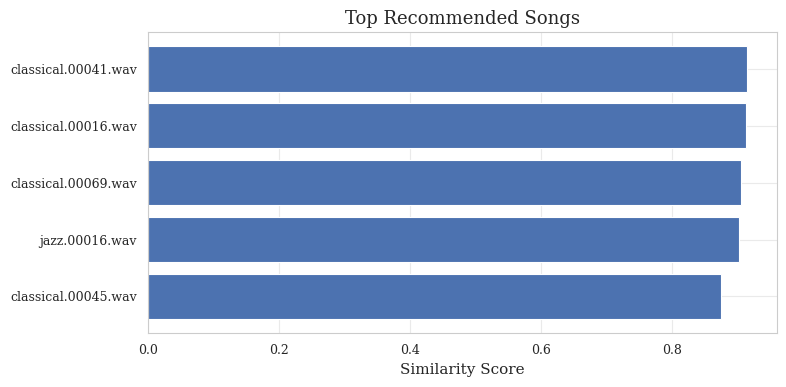


 Input Song: /content/Data/genres_original/classical/classical.00055.wav | Genre: classical

Recommended Songs:
1. /content/Data/genres_original/classical/classical.00041.wav | Genre: classical | Similarity: 0.9150000214576721
2. /content/Data/genres_original/classical/classical.00016.wav | Genre: classical | Similarity: 0.9129999876022339
3. /content/Data/genres_original/classical/classical.00069.wav | Genre: classical | Similarity: 0.9049999713897705
4. /content/Data/genres_original/jazz/jazz.00016.wav | Genre: jazz | Similarity: 0.9020000100135803
5. /content/Data/genres_original/classical/classical.00045.wav | Genre: classical | Similarity: 0.875


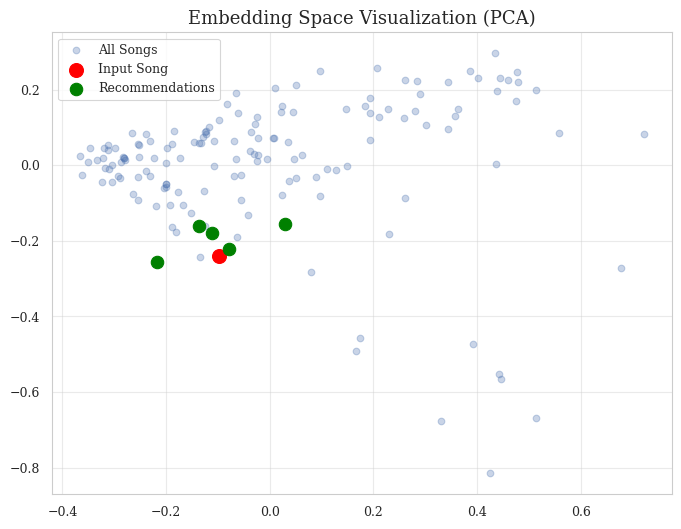


 Input Song: /content/Data/genres_original/classical/classical.00055.wav | Genre: classical

Recommended Songs:
1. /content/Data/genres_original/classical/classical.00041.wav | Genre: classical | Similarity: 0.9150000214576721
2. /content/Data/genres_original/classical/classical.00016.wav | Genre: classical | Similarity: 0.9129999876022339
3. /content/Data/genres_original/classical/classical.00069.wav | Genre: classical | Similarity: 0.9049999713897705
4. /content/Data/genres_original/jazz/jazz.00016.wav | Genre: jazz | Similarity: 0.9020000100135803
5. /content/Data/genres_original/classical/classical.00045.wav | Genre: classical | Similarity: 0.875


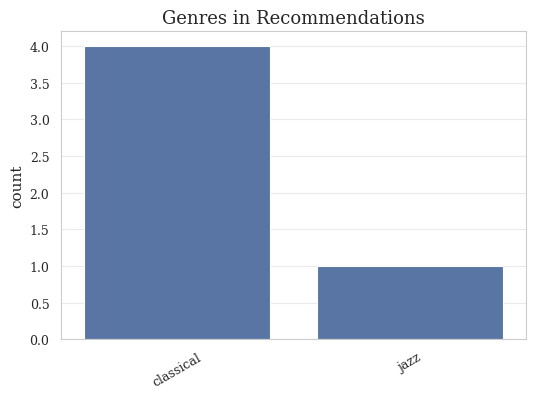

In [ ]:
# We explore a music recommendation system using embeddings learned from the MERT model.

# Prepare embeddings
embeddings_for_recommender = normalize(X_test.cpu().numpy())
labels_for_recommender = y_test.cpu().numpy()
song_ids_for_recommender = np.array(test_filepaths)

# Similarity matrix
similarity_matrix = cosine_similarity(embeddings_for_recommender)

# Recommendation function
def recommend_songs_by_index(song_idx, top_k=5, same_genre=False):

    similarity_scores = similarity_matrix[song_idx]


    sorted_indices = np.argsort(similarity_scores)[::-1]

    input_genre_id = labels_for_recommender[song_idx]
    input_genre_name = genres[input_genre_id]

    recommendations = []

    for idx in sorted_indices[1:]:  # skip the song itself

        if same_genre and labels_for_recommender[idx] != input_genre_id:
            continue

        recommendations.append((
            song_ids_for_recommender[idx],
            genres[labels_for_recommender[idx]],
            round(similarity_scores[idx], 3)
        ))

        if len(recommendations) == top_k:
            break

    print(f"\n Input Song: {song_ids_for_recommender[song_idx]} | Genre: {input_genre_name}")
    print("\nRecommended Songs:")

    for i, (sid, genre_name, score) in enumerate(recommendations, 1):
        print(f"{i}. {sid} | Genre: {genre_name} | Similarity: {score}")

    return recommendations

# Visualize the results

def visualize_recommendations(song_idx, top_k=5):
    recs = recommend_songs_by_index(song_idx, top_k)

    names = [r[0].split('/')[-1] for r in recs]
    scores = [r[2] for r in recs]

    plt.figure(figsize=(8, 4))
    plt.barh(names[::-1], scores[::-1])
    plt.xlabel("Similarity Score")
    plt.title("Top Recommended Songs")
    plt.tight_layout()
    plt.show()


# PCA Visualization
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings_for_recommender)

def plot_recommendation_space(song_idx, top_k=5):
    recs = recommend_songs_by_index(song_idx, top_k)

    rec_indices = [
        np.where(song_ids_for_recommender == r[0])[0][0]
        for r in recs
    ]

    plt.figure(figsize=(8,6))

    plt.scatter(emb_2d[:,0], emb_2d[:,1], alpha=0.3, label="All Songs")

    plt.scatter(emb_2d[song_idx,0], emb_2d[song_idx,1],
                color='red', label="Input Song", s=100)

    plt.scatter(emb_2d[rec_indices,0], emb_2d[rec_indices,1],
                color='green', label="Recommendations", s=80)

    plt.legend()
    plt.title("Embedding Space Visualization (PCA)")
    plt.show()


def plot_genre_distribution(song_idx, top_k=5):
    recs = recommend_songs_by_index(song_idx, top_k)

    genres_rec = [r[1] for r in recs]

    plt.figure(figsize=(6,4))
    sns.countplot(x=genres_rec)
    plt.title("Genres in Recommendations")
    plt.xticks(rotation=30)
    plt.show()

#Example

test_idx = 0

print("\n Pure Similarity ")
recommend_songs_by_index(test_idx, top_k=5)

print("\n Same Genre ")
recommend_songs_by_index(test_idx, top_k=5, same_genre=True)

# Visualizations
visualize_recommendations(test_idx, top_k=5)
plot_recommendation_space(test_idx, top_k=5)
plot_genre_distribution(test_idx, top_k=5)